In [61]:
import numpy as np
import matplotlib.pyplot as plt

from lymph import types, matrix
from lyscripts import utils
from lyscripts.configs import ModelConfig, GraphConfig, DistributionConfig, construct_model, add_distributions
import ocmscripts.config
from typing import Any
import numpy as np
import json

import pandas as pd

In [62]:
def get_model(
    which: str,
    load_samples: bool = True,
) -> types.Model:
    params_path = ocmscripts.config.CONFIGS_DIR / "graphs" / f"{which}.ly.yaml"
    params = utils.load_yaml_params(params_path)
    model_config = ModelConfig(**params['model'])
    graph_config = GraphConfig(**params['graph'])
    distributions = {}
    for key, item in params['distributions'].items():
        dist_config = DistributionConfig(**item)
        distributions[key] = dist_config

    model = construct_model(model_config, graph_config)
    model = add_distributions(model, distributions)

    if not load_samples:
        return model
    
    samples_path = ocmscripts.config.SAMPLES_DIR / f"{which}_bic.hdf5"
    samples = utils.load_model_samples(samples_path)
    model.set_params(*samples.mean(axis=0))

    return model

def get_samples(which: str) -> np.ndarray:
    samples_path = ocmscripts.config.SAMPLES_DIR / f"{which}_bic.hdf5"
    return utils.load_model_samples(samples_path)

def get_model_variables(which: str) -> dict[str, Any]:
    """Get the variables from the models"""
    model = get_model(which)
    samples = get_samples(which)
    names = model.get_named_params()

    means, stds = samples.mean(axis=0), samples.std(axis=0)

    variables = {}
    for name, mean, std in zip(names, means, stds):
        variables[name] = f"{mean*100:.2f}, {std*100:.2f}"
    
    return variables

def main():
    vars = get_model_variables('midline+II_I+IV_V')
    save_path = ocmscripts.config.REPORTS_DIR / 'midline+II_I+IV_V_params.json'
    with open(save_path, "w") as file:
        json.dump(vars, file, indent=2)


In [63]:
model_IV_V = get_model('midline+II_I+IV_V')
model_IV_V.set_modality('max_llh', sens=1, spec=1)

In [64]:
model_III_V = get_model('midline+II_I+III_V')
model_III_V.set_modality('max_llh', sens=1, spec=1)

In [65]:
data = pd.read_csv(ocmscripts.config.PROCESSED_DATA_DIR / 'dataset.csv', header=[0, 1, 2])
model_IV_V.load_patient_data(data)
model_III_V.load_patient_data(data)

/home/noemibuhrer/Projects/oral-cavity/oral-cavity-model-paper/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:543: DataWarning: Modality enbloc_dissected does not contain involvement data for LNL I. Assuming unknown.
  warnings.warn(
/home/noemibuhrer/Projects/oral-cavity/oral-cavity-model-paper/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:543: DataWarning: Modality enbloc_dissected does not contain involvement data for LNL II. Assuming unknown.
  warnings.warn(
/home/noemibuhrer/Projects/oral-cavity/oral-cavity-model-paper/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:543: DataWarning: Modality enbloc_dissected does not contain involvement data for LNL V. Assuming unknown.
  warnings.warn(
/home/noemibuhrer/Projects/oral-cavity/oral-cavity-model-paper/.venv/lib/python3.10/site-packages/lymph/models/unilateral.py:543: DataWarning: Modality enbloc_positive does not contain involvement data for LNL I. Assuming unknown.
  warnings.warn(
/hom

In [66]:
patient_llh_III_V = model_III_V.patient_likelihoods()
model_III_V.likelihood()

np.float64(-1106.6630318459868)

In [67]:
patient_llh_IV_V = model_IV_V.patient_likelihoods()
model_IV_V.likelihood()


np.float64(-1101.677105124311)

In [68]:
np.log(patient_llh_III_V[data['max_llh', 'contra', 'V'] == True])

array([-15.46363469,  -8.86528573,  -8.86528573,  -5.33436777,
       -16.91123714, -12.45046866])

In [69]:
np.log(patient_llh_IV_V[data['max_llh', 'contra', 'V'] == True])

array([-12.38173163,  -9.00991829,  -9.00991829,  -5.90972891,
       -11.40062343, -12.15505515])

In [70]:
np.log(patient_llh_III_V[data['max_llh', 'contra', 'V'] == False])

array([ -4.53342723,  -0.77332722,  -0.77332722,  -2.39101451,
        -0.77332722,  -2.54138028,  -0.77332722,  -0.77332722,
        -4.63796874,  -2.70990727,  -6.87883095,  -2.53680028,
        -0.77332722,  -2.39101451,  -0.77332722,  -4.91694254,
        -0.77332722,  -6.49831856,  -2.5279741 ,  -4.59063447,
        -0.77332722,  -0.77332722,  -0.77332722,  -4.07757976,
        -5.38002284,  -5.69660105,  -2.39101451,  -0.77332722,
        -5.789866  ,  -4.59653901,  -9.082665  ,  -0.77332722,
        -3.79699602,  -2.88688882,  -1.37211858,  -2.5279741 ,
        -0.77332722,  -0.77332722,  -0.77332722,  -3.75520345,
        -5.59581694,  -5.47525948,  -0.77332722,  -0.77332722,
        -2.39101451,  -2.54138028,  -5.65673212, -10.22640032,
        -2.5279741 ,  -2.39101451,  -2.5279741 ,  -5.47525948,
        -1.37211858,  -0.77332722,  -2.39101451,  -6.35875334,
        -0.77332722,  -3.94649312,  -1.37211858,  -2.88688882,
        -0.77332722,  -4.93035981,  -4.1474853 ,  -2.52

In [71]:
np.log(patient_llh_IV_V[data['max_llh', 'contra', 'V'] == False])

array([ -4.53677357,  -0.77167888,  -0.77167888,  -2.38902569,
        -0.77167888,  -2.55844023,  -0.77167888,  -0.77167888,
        -4.50423215,  -2.7090563 ,  -6.77246348,  -2.53383931,
        -0.77167888,  -2.38902569,  -0.77167888,  -4.94733471,
        -0.77167888,  -6.50193452,  -2.54089664,  -4.50688597,
        -0.77167888,  -0.77167888,  -0.77167888,  -3.91660244,
        -5.60410557,  -5.58486635,  -2.38902569,  -0.77167888,
        -5.78208828,  -4.58998326,  -9.59174789,  -0.77167888,
        -3.67741711,  -2.88447068,  -1.37259648,  -2.54089664,
        -0.77167888,  -0.77167888,  -0.77167888,  -3.77280979,
        -5.43685211,  -5.38013509,  -0.77167888,  -0.77167888,
        -2.38902569,  -2.55844023,  -5.66105755, -10.61702287,
        -2.54089664,  -2.38902569,  -2.54089664,  -5.38013509,
        -1.37259648,  -0.77167888,  -2.38902569,  -6.42128634,
        -0.77167888,  -3.85613288,  -1.37259648,  -2.88447068,
        -0.77167888,  -4.93067457,  -4.07995555,  -2.54

In [72]:
print('III -> V', '\n')
print('llh contra V inv. :', np.sum(np.log(patient_llh_III_V[data['max_llh', 'contra', 'V'] == True])))
print('llh contra V healthy :', np.sum(np.log(patient_llh_III_V[data['max_llh', 'contra', 'V'] == False])), '\n')
print('llh ipsi V inv. :', np.sum(np.log(patient_llh_III_V[data['max_llh', 'ipsi', 'V'] == True])))
print('llh ipsi V healthy :', np.sum(np.log(patient_llh_III_V[data['max_llh', 'ipsi', 'V'] == False])), '\n')
print('llh ipsi V inv. / contra V healthy :', np.sum(np.log(patient_llh_III_V[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'contra', 'V'] == False)])))
print('llh ipsi V healthy / contra V healthy :', np.sum(np.log(patient_llh_III_V[(data['max_llh', 'ipsi', 'V'] == False) & (data['max_llh', 'contra', 'V'] == False)])))
print('llh ipsi V inv. / contra V inv :', np.sum(np.log(patient_llh_III_V[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'contra', 'V'] == True)])))
print('llh ipsi V healthy / contra V inv :', np.sum(np.log(patient_llh_III_V[(data['max_llh', 'ipsi', 'V'] == False) & (data['max_llh', 'contra', 'V'] == True)])))

III -> V 

llh contra V inv. : -67.89027972713079
llh contra V healthy : -1038.772752118856 

llh ipsi V inv. : -129.46656788106054
llh ipsi V healthy : -977.1964639649261 

llh ipsi V inv. / contra V healthy : -84.64122738761627
llh ipsi V healthy / contra V healthy : -954.1315247312398
llh ipsi V inv. / contra V inv : -44.825340493444266
llh ipsi V healthy / contra V inv : -23.064939233686506


In [73]:
print('IV -> V', '\n')
print('llh contra V inv. :', np.sum(np.log(patient_llh_IV_V[data['max_llh', 'contra', 'V'] == True])))
print('llh contra V healthy :', np.sum(np.log(patient_llh_IV_V[data['max_llh', 'contra', 'V'] == False])), '\n')
print('llh ipsi V inv. :', np.sum(np.log(patient_llh_IV_V[data['max_llh', 'ipsi', 'V'] == True])))
print('llh ipsi V healthy :', np.sum(np.log(patient_llh_IV_V[data['max_llh', 'ipsi', 'V'] == False])), '\n')
print('llh ipsi V inv. / contra V healthy :', np.sum(np.log(patient_llh_IV_V[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'contra', 'V'] == False)])))
print('llh ipsi V healthy / contra V healthy :', np.sum(np.log(patient_llh_IV_V[(data['max_llh', 'ipsi', 'V'] == False) & (data['max_llh', 'contra', 'V'] == False)])))
print('llh ipsi V inv. / contra V inv. :', np.sum(np.log(patient_llh_IV_V[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'contra', 'V'] == True)])))
print('llh ipsi V healthy / contra V inv. :', np.sum(np.log(patient_llh_IV_V[(data['max_llh', 'ipsi', 'V'] == False) & (data['max_llh', 'contra', 'V'] == True)])))

IV -> V 

llh contra V inv. : -59.866975688289884
llh contra V healthy : -1041.8101294360208 

llh ipsi V inv. : -123.9994431398483
llh ipsi V healthy : -977.6776619844626 

llh ipsi V inv. / contra V healthy : -88.06203293062217
llh ipsi V healthy / contra V healthy : -953.7480965053987
llh ipsi V inv. / contra V inv. : -35.93741020922613
llh ipsi V healthy / contra V inv. : -23.92956547906375


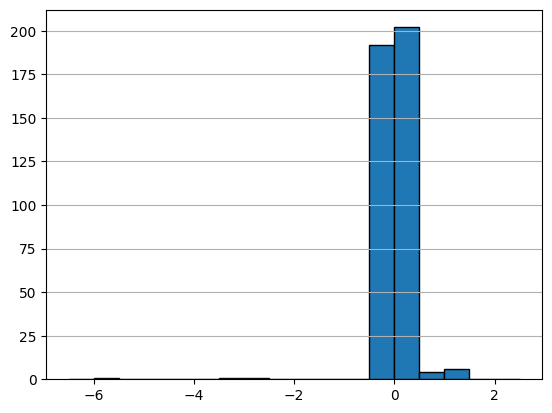

In [74]:
plt.figure()
plt.hist(np.log(patient_llh_III_V) - np.log(patient_llh_IV_V), range = (-6.5, 2.5), bins = 18, histtype='bar', edgecolor='black')
#plt.yscale('log')
plt.grid(axis='y')
plt.show()

In [78]:
np.sum(data['patient', 'core', 'llh_diff'].loc[data['patient', 'core', 'llh_diff'].abs() < 2])

np.float64(6.194720406336579)

In [79]:
np.sum(data['patient', 'core', 'llh_diff'].loc[data['patient', 'core', 'llh_diff'].abs() > 2])

np.float64(-11.180647128012485)

In [76]:
IPSI_LNL = [('max_llh', 'ipsi', 'I'), ('max_llh', 'ipsi', 'II'), ('max_llh', 'ipsi', 'III'), ('max_llh', 'ipsi', 'IV'), ('max_llh', 'ipsi', 'V')]
CONTRA_LNL = [('max_llh', 'contra', 'I'), ('max_llh', 'contra', 'II'), ('max_llh', 'contra', 'III'), ('max_llh', 'contra', 'IV'), ('max_llh', 'contra', 'V')]

In [77]:
data['patient', 'core', 'llh_diff'] = np.log(model_III_V.patient_likelihoods()) - np.log(model_IV_V.patient_likelihoods())
data['patient', 'core', 'llh_III_V'] = np.log(model_III_V.patient_likelihoods())
data['patient', 'core', 'llh_IV_V'] = np.log(model_IV_V.patient_likelihoods())

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]][np.log(patient_llh_III_V) - np.log(patient_llh_IV_V) < -2]

patient max_llh                                                \
             core    ipsi                          contra                 
               id       I    II    III    IV     V      I     II    III   
218  2023-CLB-034   False  True   True  True  True  False  False  False   
345  2023-CLB-361   False  True  False  True  True   True   True   True   
351   2025-KSA-04    True  True  False  True  True  False  False  False   

                     patient                       
                        core                       
        IV      V  llh_III_V   llh_IV_V  llh_diff  
218   True   True -15.426723 -12.345080 -3.081643  
345  False  False -13.251333 -10.621163 -2.630170  
351   True   True -16.915007 -11.373701 -5.541307

In [80]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]][np.log(patient_llh_III_V) - np.log(patient_llh_IV_V) < -2].sum()

patient  core    id           2023-CLB-0342023-CLB-3612025-KSA-04
max_llh  ipsi    I                                              1
                 II                                             3
                 III                                            1
                 IV                                             3
                 V                                              3
         contra  I                                              1
                 II                                             1
                 III                                            1
                 IV                                             2
                 V                                              2
patient  core    llh_III_V                             -45.601929
                 llh_IV_V                              -34.421282
                 llh_diff                              -11.180647
dtype: object

In [81]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]][np.log(patient_llh_III_V) - np.log(patient_llh_IV_V) > -2]

patient max_llh                                                   \
             core    ipsi                             contra                 
               id       I     II    III     IV      V      I     II    III   
0    2023-ISB-002   False  False  False  False  False   True  False  False   
1    2023-ISB-003   False  False  False  False  False  False  False  False   
2    2023-ISB-004   False  False  False  False  False  False  False  False   
3    2023-ISB-005   False   True  False  False  False  False  False  False   
4    2023-ISB-006   False  False  False  False  False  False  False  False   
..            ...     ...    ...    ...    ...    ...    ...    ...    ...   
402   2025-KSA-62   False  False  False  False  False  False  False  False   
403   2025-KSA-63   False  False  False  False  False  False  False  False   
404   2025-KSA-64   False  False  False  False  False  False  False  False   
405   2025-KSA-65   False  False  False  False  False  False  False  False   
406   2025-KSA-66   False  False  False  False  False  False  False  False   

                    patient                      
                       core                      
        IV      V llh_III_V  llh_IV_V  llh_diff  
0    False  False -4.533427 -4.536774  0.003346  
1    False  False -0.773327 -0.771679 -0.001648  
2    False  False -0.773327 -0.771679 -0.001648  
3    False  False -2.391015 -2.389026 -0.001989  
4    False  False -0.773327 -0.771679 -0.001648  
..     ...    ...       ...       ...       ...  
402  False  False -2.527974 -2.540897  0.012923  
403  False  False -1.372119 -1.372596  0.000478  
404  False  False -0.773327 -0.771679 -0.001648  
405  False  False -1.372119 -1.372596  0.000478  
406  False  False -1.372119 -1.372596  0.000478  

[404 rows x 14 columns]

In [82]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]][np.log(patient_llh_III_V) - np.log(patient_llh_IV_V) > -2].sum()

patient  core    id           2023-ISB-0022023-ISB-0032023-ISB-0042023-ISB-0...
max_llh  ipsi    I                                                           87
                 II                                                         116
                 III                                                         51
                 IV                                                          14
                 V                                                           12
         contra  I                                                           28
                 II                                                          23
                 III                                                         11
                 IV                                                           5
                 V                                                            4
patient  core    llh_III_V                                         -1061.061102
                 llh_IV_V               

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'contra', 'V'] == True)]

patient max_llh                                                   \
             core    ipsi                             contra                 
               id       I     II    III     IV      V      I     II    III   
218  2023-CLB-034   False   True   True   True   True  False  False  False   
250  2023-CLB-066   False   True  False  False  False  False   True  False   
318  2023-CLB-292   False   True  False  False  False  False   True  False   
337  2023-CLB-332   False  False  False  False  False  False  False  False   
351   2025-KSA-04    True   True  False   True   True  False  False  False   
362   2025-KSA-17    True   True   True   True   True   True   True   True   

                    patient                       
                       core                       
        IV     V  llh_III_V   llh_IV_V  llh_diff  
218   True  True -15.426723 -12.345080 -3.081643  
250  False  True  -8.869225  -9.021940  0.152715  
318  False  True  -8.869225  -9.021940  0.152715  
337  False  True  -5.325337  -5.914874  0.589537  
351   True  True -16.915007 -11.373701 -5.541307  
362   True  True -12.397084 -12.099360 -0.297724

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'contra', 'V'] == True)].sum()

patient  core    id           2023-CLB-0342023-CLB-0662023-CLB-2922023-CLB-3...
max_llh  ipsi    I                                                            2
                 II                                                           5
                 III                                                          2
                 IV                                                           3
                 V                                                            3
         contra  I                                                            1
                 II                                                           3
                 III                                                          1
                 IV                                                           3
                 V                                                            6
patient  core    llh_III_V                                           -67.802601
                 llh_IV_V               

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'contra', 'V'] == True) & (data['max_llh', 'contra', 'III'] == True)].sum()

patient  core    id           2025-KSA-17
max_llh  ipsi    I                      1
                 II                     1
                 III                    1
                 IV                     1
                 V                      1
         contra  I                      1
                 II                     1
                 III                    1
                 IV                     1
                 V                      1
patient  core    llh_III_V     -12.397084
                 llh_IV_V       -12.09936
                 llh_diff       -0.297724
dtype: object

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'contra', 'V'] == True) & (data['max_llh', 'contra', 'IV'] == True)].sum()

patient  core    id           2023-CLB-0342025-KSA-042025-KSA-17
max_llh  ipsi    I                                             2
                 II                                            3
                 III                                           2
                 IV                                            3
                 V                                             3
         contra  I                                             1
                 II                                            1
                 III                                           1
                 IV                                            3
                 V                                             3
patient  core    llh_III_V                            -44.738815
                 llh_IV_V                             -35.818141
                 llh_diff                              -8.920673
dtype: object

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'ipsi', 'V'] == True)]

patient max_llh                                                  \
             core    ipsi                            contra                 
               id       I     II    III     IV     V      I     II    III   
93   2023-ISB-095   False  False   True  False  True  False  False  False   
218  2023-CLB-034   False   True   True   True  True  False  False  False   
225  2023-CLB-041   False  False  False  False  True  False  False  False   
238  2023-CLB-054   False   True  False  False  True  False   True  False   
244  2023-CLB-060   False   True  False  False  True  False  False  False   
325  2023-CLB-315   False   True   True  False  True  False  False  False   
332  2023-CLB-327    True   True  False  False  True  False  False  False   
341  2023-CLB-354   False  False   True  False  True  False  False  False   
343  2023-CLB-359   False   True  False  False  True  False  False  False   
345  2023-CLB-361   False   True  False   True  True   True   True   True   
351   2025-KSA-04    True   True  False   True  True  False  False  False   
361   2025-KSA-16    True   True   True  False  True  False  False  False   
362   2025-KSA-17    True   True   True   True  True   True   True   True   
394   2025-KSA-54   False  False   True  False  True  False  False  False   
399   2025-KSA-59   False   True   True  False  True  False  False  False   

                     patient                       
                        core                       
        IV      V  llh_III_V   llh_IV_V  llh_diff  
93   False  False  -7.445177  -8.860206  1.415029  
218   True   True -15.426723 -12.345080 -3.081643  
225  False  False  -4.736506  -4.457690 -0.278816  
238  False  False  -9.214658  -8.941674 -0.272984  
244  False  False  -6.105536  -5.827884 -0.277652  
325  False  False  -5.284531  -6.433107  1.148576  
332  False  False  -6.832229  -6.563421 -0.268807  
341  False  False  -5.890626  -7.265085  1.374458  
343  False  False  -5.701802  -5.418074 -0.283727  
345  False  False -13.251333 -10.621163 -2.630170  
351   True   True -16.915007 -11.373701 -5.541307  
361  False  False  -7.759571  -8.956524  1.196953  
362   True   True -12.397084 -12.099360 -0.297724  
394  False  False  -6.646993  -8.086973  1.439980  
399  False  False  -5.620739  -6.762094  1.141355

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'ipsi', 'V'] == True)].sum()

patient  core    id           2023-ISB-0952023-CLB-0342023-CLB-0412023-CLB-0...
max_llh  ipsi    I                                                            4
                 II                                                          11
                 III                                                          8
                 IV                                                           4
                 V                                                           15
         contra  I                                                            2
                 II                                                           3
                 III                                                          2
                 IV                                                           3
                 V                                                            3
patient  core    llh_III_V                                          -129.228516
                 llh_IV_V               

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'ipsi', 'IV'] == True)].sum()


patient  core    id           2023-CLB-0342023-CLB-3612025-KSA-042025-KSA-17
max_llh  ipsi    I                                                         2
                 II                                                        4
                 III                                                       2
                 IV                                                        4
                 V                                                         4
         contra  I                                                         2
                 II                                                        2
                 III                                                       2
                 IV                                                        3
                 V                                                         3
patient  core    llh_III_V                                        -57.990147
                 llh_IV_V                                         -46.439304

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'ipsi', 'III'] == True)].sum()

patient  core    id           2023-ISB-0952023-CLB-0342023-CLB-3152023-CLB-3...
max_llh  ipsi    I                                                            2
                 II                                                           5
                 III                                                          8
                 IV                                                           2
                 V                                                            8
         contra  I                                                            1
                 II                                                           1
                 III                                                          1
                 IV                                                           2
                 V                                                            2
patient  core    llh_III_V                                           -66.471446
                 llh_IV_V               

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'ipsi', 'V'] == True)]

patient max_llh                                                  \
             core    ipsi                            contra                 
               id       I     II    III     IV     V      I     II    III   
93   2023-ISB-095   False  False   True  False  True  False  False  False   
218  2023-CLB-034   False   True   True   True  True  False  False  False   
225  2023-CLB-041   False  False  False  False  True  False  False  False   
238  2023-CLB-054   False   True  False  False  True  False   True  False   
244  2023-CLB-060   False   True  False  False  True  False  False  False   
325  2023-CLB-315   False   True   True  False  True  False  False  False   
332  2023-CLB-327    True   True  False  False  True  False  False  False   
341  2023-CLB-354   False  False   True  False  True  False  False  False   
343  2023-CLB-359   False   True  False  False  True  False  False  False   
345  2023-CLB-361   False   True  False   True  True   True   True   True   
351   2025-KSA-04    True   True  False   True  True  False  False  False   
361   2025-KSA-16    True   True   True  False  True  False  False  False   
362   2025-KSA-17    True   True   True   True  True   True   True   True   
394   2025-KSA-54   False  False   True  False  True  False  False  False   
399   2025-KSA-59   False   True   True  False  True  False  False  False   

                     patient                       
                        core                       
        IV      V  llh_III_V   llh_IV_V  llh_diff  
93   False  False  -7.445177  -8.860206  1.415029  
218   True   True -15.426723 -12.345080 -3.081643  
225  False  False  -4.736506  -4.457690 -0.278816  
238  False  False  -9.214658  -8.941674 -0.272984  
244  False  False  -6.105536  -5.827884 -0.277652  
325  False  False  -5.284531  -6.433107  1.148576  
332  False  False  -6.832229  -6.563421 -0.268807  
341  False  False  -5.890626  -7.265085  1.374458  
343  False  False  -5.701802  -5.418074 -0.283727  
345  False  False -13.251333 -10.621163 -2.630170  
351   True   True -16.915007 -11.373701 -5.541307  
361  False  False  -7.759571  -8.956524  1.196953  
362   True   True -12.397084 -12.099360 -0.297724  
394  False  False  -6.646993  -8.086973  1.439980  
399  False  False  -5.620739  -6.762094  1.141355

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'contra', 'V'] == True) & (data['max_llh', 'ipsi', 'V'] == False)]

patient max_llh                                                   \
             core    ipsi                             contra                 
               id       I     II    III     IV      V      I     II    III   
250  2023-CLB-066   False   True  False  False  False  False   True  False   
318  2023-CLB-292   False   True  False  False  False  False   True  False   
337  2023-CLB-332   False  False  False  False  False  False  False  False   

                   patient                      
                      core                      
        IV     V llh_III_V  llh_IV_V  llh_diff  
250  False  True -8.869225 -9.021940  0.152715  
318  False  True -8.869225 -9.021940  0.152715  
337  False  True -5.325337 -5.914874  0.589537

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]][np.log(patient_llh_III_V) - np.log(patient_llh_IV_V) > 1]

patient max_llh                                                 \
             core    ipsi                           contra                 
               id       I     II   III     IV     V      I     II    III   
93   2023-ISB-095   False  False  True  False  True  False  False  False   
325  2023-CLB-315   False   True  True  False  True  False  False  False   
341  2023-CLB-354   False  False  True  False  True  False  False  False   
361   2025-KSA-16    True   True  True  False  True  False  False  False   
394   2025-KSA-54   False  False  True  False  True  False  False  False   
399   2025-KSA-59   False   True  True  False  True  False  False  False   

                    patient                      
                       core                      
        IV      V llh_III_V  llh_IV_V  llh_diff  
93   False  False -7.445177 -8.860206  1.415029  
325  False  False -5.284531 -6.433107  1.148576  
341  False  False -5.890626 -7.265085  1.374458  
361  False  False -7.759571 -8.956524  1.196953  
394  False  False -6.646993 -8.086973  1.439980  
399  False  False -5.620739 -6.762094  1.141355

In [ ]:
np.sum((np.log(patient_llh_III_V) - np.log(patient_llh_IV_V)) > 0)

np.int64(191)

In [ ]:
np.sum((np.log(patient_llh_III_V) - np.log(patient_llh_IV_V)) < 0)

np.int64(216)

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'contra', 'V'] == True) & (data['max_llh', 'contra', 'IV'] == True)]

patient max_llh                                                      \
             core    ipsi                          contra                       
               id       I    II    III    IV     V      I     II    III    IV   
218  2023-CLB-034   False  True   True  True  True  False  False  False  True   
351   2025-KSA-04    True  True  False  True  True  False  False  False  True   
362   2025-KSA-17    True  True   True  True  True   True   True   True  True   

             patient                       
                core                       
        V  llh_III_V   llh_IV_V  llh_diff  
218  True -15.426723 -12.345080 -3.081643  
351  True -16.915007 -11.373701 -5.541307  
362  True -12.397084 -12.099360 -0.297724

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'contra', 'V'] == True) & (data['max_llh', 'contra', 'III'] == True)]

patient max_llh                                                   \
            core    ipsi                         contra                     
              id       I    II   III    IV     V      I    II   III    IV   
362  2025-KSA-17    True  True  True  True  True   True  True  True  True   

             patient                      
                core                      
        V  llh_III_V  llh_IV_V  llh_diff  
362  True -12.397084 -12.09936 -0.297724

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'ipsi', 'IV'] == True)]

patient max_llh                                                \
             core    ipsi                          contra                 
               id       I    II    III    IV     V      I     II    III   
218  2023-CLB-034   False  True   True  True  True  False  False  False   
345  2023-CLB-361   False  True  False  True  True   True   True   True   
351   2025-KSA-04    True  True  False  True  True  False  False  False   
362   2025-KSA-17    True  True   True  True  True   True   True   True   

                     patient                       
                        core                       
        IV      V  llh_III_V   llh_IV_V  llh_diff  
218   True   True -15.426723 -12.345080 -3.081643  
345  False  False -13.251333 -10.621163 -2.630170  
351   True   True -16.915007 -11.373701 -5.541307  
362   True   True -12.397084 -12.099360 -0.297724

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[(data['max_llh', 'ipsi', 'V'] == True) & (data['max_llh', 'ipsi', 'III'] == True)]

patient max_llh                                                 \
             core    ipsi                           contra                 
               id       I     II   III     IV     V      I     II    III   
93   2023-ISB-095   False  False  True  False  True  False  False  False   
218  2023-CLB-034   False   True  True   True  True  False  False  False   
325  2023-CLB-315   False   True  True  False  True  False  False  False   
341  2023-CLB-354   False  False  True  False  True  False  False  False   
361   2025-KSA-16    True   True  True  False  True  False  False  False   
362   2025-KSA-17    True   True  True   True  True   True   True   True   
394   2025-KSA-54   False  False  True  False  True  False  False  False   
399   2025-KSA-59   False   True  True  False  True  False  False  False   

                     patient                       
                        core                       
        IV      V  llh_III_V   llh_IV_V  llh_diff  
93   False  False  -7.445177  -8.860206  1.415029  
218   True   True -15.426723 -12.345080 -3.081643  
325  False  False  -5.284531  -6.433107  1.148576  
341  False  False  -5.890626  -7.265085  1.374458  
361  False  False  -7.759571  -8.956524  1.196953  
362   True   True -12.397084 -12.099360 -0.297724  
394  False  False  -6.646993  -8.086973  1.439980  
399  False  False  -5.620739  -6.762094  1.141355

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[data[CONTRA_LNL].any(axis=1) == False].sort_values(by=('patient', 'core', 'llh_diff'))

patient max_llh                                                   \
             core    ipsi                             contra                 
               id       I     II    III     IV      V      I     II    III   
343  2023-CLB-359   False   True  False  False   True  False  False  False   
225  2023-CLB-041   False  False  False  False   True  False  False  False   
244  2023-CLB-060   False   True  False  False   True  False  False  False   
332  2023-CLB-327    True   True  False  False   True  False  False  False   
194  2023-ISB-271   False  False   True  False  False  False  False  False   
..            ...     ...    ...    ...    ...    ...    ...    ...    ...   
325  2023-CLB-315   False   True   True  False   True  False  False  False   
361   2025-KSA-16    True   True   True  False   True  False  False  False   
341  2023-CLB-354   False  False   True  False   True  False  False  False   
93   2023-ISB-095   False  False   True  False   True  False  False  False   
394   2025-KSA-54   False  False   True  False   True  False  False  False   

                    patient                      
                       core                      
        IV      V llh_III_V  llh_IV_V  llh_diff  
343  False  False -5.701802 -5.418074 -0.283727  
225  False  False -4.736506 -4.457690 -0.278816  
244  False  False -6.105536 -5.827884 -0.277652  
332  False  False -6.832229 -6.563421 -0.268807  
194  False  False -5.168084 -5.001344 -0.166740  
..     ...    ...       ...       ...       ...  
325  False  False -5.284531 -6.433107  1.148576  
361  False  False -7.759571 -8.956524  1.196953  
341  False  False -5.890626 -7.265085  1.374458  
93   False  False -7.445177 -8.860206  1.415029  
394  False  False -6.646993 -8.086973  1.439980  

[355 rows x 14 columns]

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[data[CONTRA_LNL].any(axis=1) == True].sort_values(by=('patient', 'core', 'llh_diff'))

patient max_llh                                                   \
             core    ipsi                             contra                 
               id       I     II    III     IV      V      I     II    III   
351   2025-KSA-04    True   True  False   True   True  False  False  False   
218  2023-CLB-034   False   True   True   True   True  False  False  False   
345  2023-CLB-361   False   True  False   True   True   True   True   True   
223  2023-CLB-039    True  False   True  False  False   True  False   True   
79   2023-ISB-081    True   True   True  False  False  False  False   True   
362   2025-KSA-17    True   True   True   True   True   True   True   True   
305  2023-CLB-273    True  False   True  False  False   True  False   True   
238  2023-CLB-054   False   True  False  False   True  False   True  False   
68   2023-ISB-070    True  False   True  False  False   True  False  False   
95   2023-ISB-097   False   True   True  False  False  False   True   True   
123  2023-ISB-198   False   True   True  False  False  False   True  False   
40   2023-ISB-042   False  False  False  False  False  False  False   True   
302  2023-CLB-173   False  False  False  False  False  False   True   True   
10   2023-ISB-012   False   True  False  False  False  False  False   True   
303  2023-CLB-271   False   True  False  False  False  False  False   True   
270  2023-CLB-086   False   True  False  False  False  False  False   True   
158  2023-ISB-234    True   True   True  False  False  False   True  False   
398   2025-KSA-58    True   True   True   True  False   True   True   True   
390   2025-KSA-50    True  False  False  False  False   True   True  False   
380   2025-KSA-40   False   True  False  False  False  False   True  False   
384   2025-KSA-44    True   True  False  False  False   True   True  False   
377   2025-KSA-37    True   True  False  False  False   True   True  False   
369   2025-KSA-28    True   True  False  False  False  False   True  False   
364   2025-KSA-21   False  False  False  False  False   True  False  False   
61   2023-ISB-063   False  False  False  False  False   True  False  False   
104  2023-ISB-173    True  False  False  False  False   True  False  False   
46   2023-ISB-048    True  False  False  False  False   True  False  False   
366   2025-KSA-23   False  False  False  False  False   True  False  False   
0    2023-ISB-002   False  False  False  False  False   True  False  False   
316  2023-CLB-290    True  False  False  False  False  False   True  False   
17   2023-ISB-019    True  False  False  False  False   True  False  False   
256  2023-CLB-072   False  False  False  False  False   True  False  False   
240  2023-CLB-056    True   True  False  False  False   True  False  False   
268  2023-CLB-084   False  False  False  False  False   True  False  False   
334  2023-CLB-329   False  False  False  False  False   True  False  False   
28   2023-ISB-030    True  False  False  False  False   True  False  False   
283  2023-CLB-099   False  False  False  False  False   True   True  False   
91   2023-ISB-093   False  False  False  False  False   True  False  False   
29   2023-ISB-031   False  False  False  False  False   True  False  False   
375   2025-KSA-35    True   True  False  False  False  False   True  False   
15   2023-ISB-017   False  False  False  False  False  False   True  False   
130  2023-ISB-205   False  False  False  False  False  False   True  False   
180  2023-ISB-256    True  False  False  False  False   True   True  False   
318  2023-CLB-292   False   True  False  False  False  False   True  False   
250  2023-CLB-066   False   True  False  False  False  False   True  False   
24   2023-ISB-026   False  False  False  False  False  False  False  False   
47   2023-ISB-049   False  False  False   True  False   True   True  False   
237  2023-CLB-053    True   True  False  False  False   True   True  False   
30   2023-ISB-032    True  False

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[data[CONTRA_LNL].any(axis=1) == False].sum(axis=0)

patient  core    id           2023-ISB-0032023-ISB-0042023-ISB-0052023-ISB-0...
max_llh  ipsi    I                                                           65
                 II                                                          95
                 III                                                         42
                 IV                                                          10
                 V                                                           10
         contra  I                                                            0
                 II                                                           0
                 III                                                          0
                 IV                                                           0
                 V                                                            0
patient  core    llh_III_V                                          -725.029327
                 llh_IV_V               

In [ ]:
data[[('patient', 'core', 'id'), *IPSI_LNL, *CONTRA_LNL, ('patient', 'core', 'llh_III_V'), ('patient', 'core', 'llh_IV_V'), ('patient', 'core', 'llh_diff')]].loc[data[CONTRA_LNL].any(axis=1) == True].sort_values(by=('patient', 'core', 'llh_diff')).sum(axis=0)

patient  core    id           2025-KSA-042023-CLB-0342023-CLB-3612023-CLB-03...
max_llh  ipsi    I                                                           23
                 II                                                          24
                 III                                                         10
                 IV                                                           7
                 V                                                            5
         contra  I                                                           29
                 II                                                          24
                 III                                                         12
                 IV                                                           7
                 V                                                            6
patient  core    llh_III_V                                          -381.677062
                 llh_IV_V               